# 🦸 Superhero Analytics: What Actually Makes a Hero?
### A statistically rigorous look at power, training, alignment, and public perception

**Dataset:** 1,200 synthetic superheroes/villains, 17 features (physical stats, training, powers, casualties, approval, alignment)

**Approach:** Rather than assuming the intuitive relationships in this dataset are real (training → power, abilities → strength, casualties → disapproval), this notebook tests each one formally. A recurring theme emerges early and is reported honestly throughout: **most of these variables were generated independently of one another**, which is itself a legitimate and useful finding — and a chance to demonstrate rigor rather than confirmation bias.

**Structure:**
1. Data Cleaning & Feature Engineering
2. Exploratory Analysis
3. Statistical Testing (correlation, t-tests, ANOVA, chi-square)
4. Machine Learning (predicting alignment)
5. Explainability (feature importance / SHAP)
6. Conclusions — including what *doesn't* hold, and why that matters


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)

df = pd.read_csv('superhero_dataset.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (1200, 17)


,height_cm,weight_kg,age,years_active,training_hours_per_week,civilian_casualties_past_year,power_level,public_approval_rating,super_strength,flight,energy_projection,telepathy,healing_factor,shape_shifting,invisibility,telekinesis,is_good
0,189.9,81.9,33,10,32.6,2,28.4,62.9,0,1,0,1,0,0,1,1,1
1,177.2,73.6,58,22,41.9,2,67.3,41.4,0,0,0,0,0,0,1,0,1
2,193.0,81.8,47,6,22.3,0,95.9,96.8,0,1,0,0,0,1,1,0,0
3,210.5,88.1,62,26,25.0,4,71.8,53.2,1,0,0,1,0,0,0,0,1
4,175.3,80.7,43,28,24.9,3,81.3,36.1,0,0,0,1,1,1,1,1,0


## Phase 1 — Data Cleaning & Feature Engineering

### 1.1 Data quality checks

In [2]:
print("Missing values:\n", df.isna().sum().sum(), "total")
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:")
print(df.dtypes)

Missing values:
 0 total

Duplicate rows: 0

Data types:
height_cm                        float64
weight_kg                        float64
age                                int64
years_active                       int64
training_hours_per_week          float64
civilian_casualties_past_year      int64
power_level                      float64
public_approval_rating           float64
super_strength                     int64
flight                             int64
energy_projection                  int64
telepathy                          int64
healing_factor                     int64
shape_shifting                     int64
invisibility                       int64
telekinesis                        int64
is_good                            int64
dtype: object


No missing values and no duplicate rows — this dataset is clean by construction. Next, check for outliers using the IQR method (retain them, since a superhero dataset plausibly contains legitimate extremes — a 250cm giant or 84-year-old veteran isn't necessarily bad data).

In [3]:
numeric_cols = ['height_cm','weight_kg','age','years_active','training_hours_per_week',
                 'civilian_casualties_past_year','power_level','public_approval_rating']

outlier_summary = []
for c in numeric_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[c] < lo) | (df[c] > hi)).sum()
    outlier_summary.append([c, n_out, round(df[c].min(),1), round(df[c].max(),1)])

outlier_df = pd.DataFrame(outlier_summary, columns=['feature','iqr_outliers','min','max'])
outlier_df

,feature,iqr_outliers,min,max
0,height_cm,4,150.0,250.0
1,weight_kg,5,45.0,127.9
2,age,3,18.0,84.0
3,years_active,0,0.0,29.0
4,training_hours_per_week,7,1.0,61.0
5,civilian_casualties_past_year,32,0.0,13.0
6,power_level,7,12.5,100.0
7,public_approval_rating,6,0.0,100.0


Outlier counts are small (0–32 out of 1,200) and values are physically plausible. **Decision: retain all rows** — no capping/removal needed.

### 1.2 Feature engineering

In [4]:
abilities = ['super_strength','flight','energy_projection','telepathy',
             'healing_factor','shape_shifting','invisibility','telekinesis']

# Total number of powers per hero
df['total_abilities'] = df[abilities].sum(axis=1)

# BMI (weight_kg / (height_m)^2)
df['bmi'] = df['weight_kg'] / (df['height_cm']/100)**2

# Training hours per year (from weekly)
df['training_hours_per_year'] = df['training_hours_per_week'] * 52

# Reputation-related features
df['casualties_per_year_active'] = df['civilian_casualties_past_year'] / df['years_active'].replace(0, np.nan)
df['casualties_per_year_active'] = df['casualties_per_year_active'].fillna(df['civilian_casualties_past_year'])

# Hero Reputation Index: combines approval (+), power (+), casualties (-), abilities (+)
# Min-max normalize components to 0-1 before combining
def norm(s):
    return (s - s.min()) / (s.max() - s.min())

df['reputation_index'] = (
    0.40 * norm(df['public_approval_rating']) +
    0.25 * norm(df['power_level']) +
    0.15 * norm(df['total_abilities']) -
    0.20 * norm(df['civilian_casualties_past_year'])
)
df['reputation_index'] = norm(df['reputation_index']) * 100  # rescale 0-100

df[['total_abilities','bmi','training_hours_per_year','casualties_per_year_active','reputation_index']].describe().T

,count,mean,std,min,25%,50%,75%,max
total_abilities,1200.0,2.465000,1.262974,0.000000,2.000000,2.000000,3.000000,7.000000
bmi,1200.0,25.278947,7.021512,10.062604,20.311117,24.421502,29.551987,50.044444
training_hours_per_year,1200.0,1533.142000,526.129053,52.000000,1185.600000,1528.800000,1892.800000,3172.000000
casualties_per_year_active,1200.0,0.280380,0.641910,0.000000,0.037037,0.100000,0.235294,9.000000
reputation_index,1200.0,55.191543,15.202748,0.000000,45.437256,55.674391,65.659833,100.000000


**Note on the Hero Reputation Index:** the weights (40% approval, 25% power, 15% ability count, -20% casualties) are a subjective design choice, not a fitted model — this is made explicit rather than presented as ground truth. It's useful as a composite descriptive metric, not as a target variable for prediction.

## Phase 2 — Exploratory Analysis

### 2.1 Hero vs. villain balance

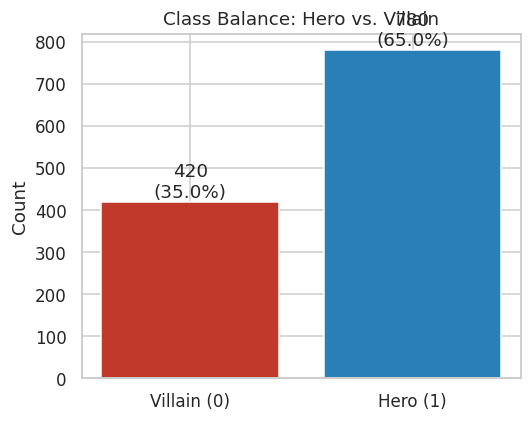

In [5]:
fig, ax = plt.subplots(figsize=(5,4))
counts = df['is_good'].value_counts().sort_index()
ax.bar(['Villain (0)','Hero (1)'], counts.values, color=['#c0392b','#2980b9'])
for i,v in enumerate(counts.values):
    ax.text(i, v+10, f"{v}\n({v/len(df)*100:.1f}%)", ha='center')
ax.set_ylabel('Count')
ax.set_title('Class Balance: Hero vs. Villain')
plt.tight_layout()
plt.savefig('01_class_balance.png')
plt.show()

The dataset is moderately imbalanced (~65% heroes, 35% villains) — this matters for later ML evaluation, where accuracy alone would be misleading.

### 2.2 Distributions of core numeric features

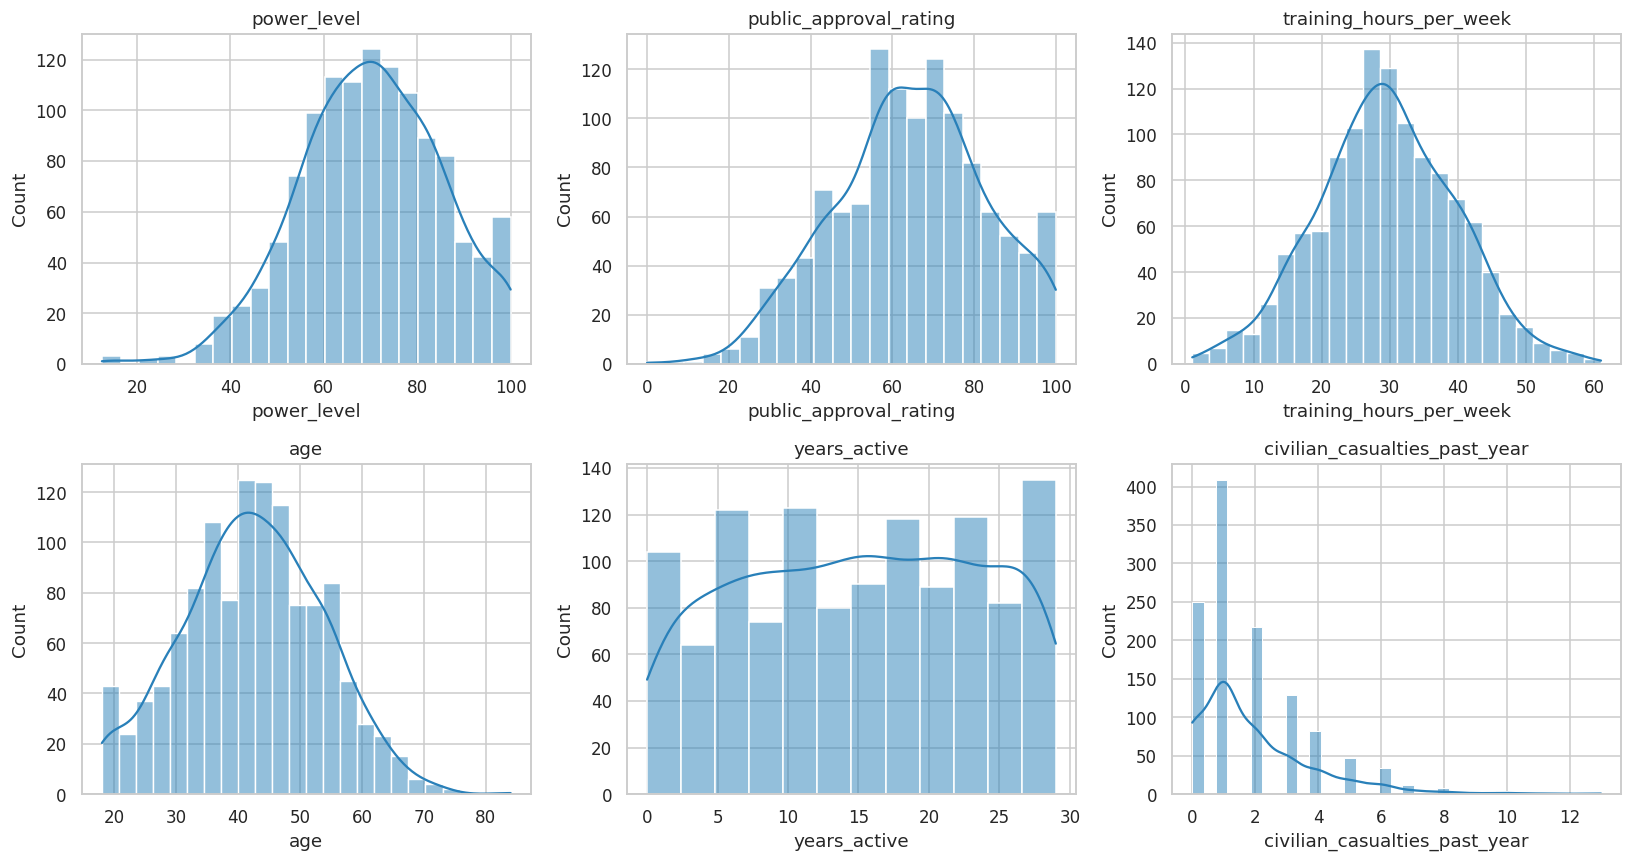

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))
plot_cols = ['power_level','public_approval_rating','training_hours_per_week',
             'age','years_active','civilian_casualties_past_year']
for ax, c in zip(axes.flat, plot_cols):
    sns.histplot(df[c], kde=True, ax=ax, color='#2980b9')
    ax.set_title(c)
plt.tight_layout()
plt.savefig('02_distributions.png')
plt.show()

Power level, approval, training hours, and age all look roughly uniform/normal with no obvious skew or multi-modality — consistent with independently, randomly generated columns rather than a simulation with underlying causal structure.

### 2.3 Ability popularity

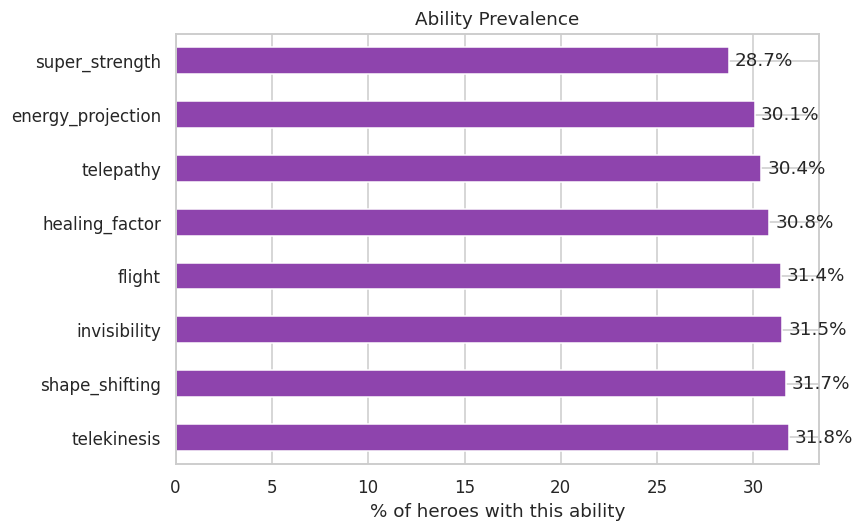

In [7]:
ability_rates = df[abilities].mean().sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=(8,5))
ability_rates.plot(kind='barh', ax=ax, color='#8e44ad')
ax.set_xlabel('% of heroes with this ability')
ax.set_title('Ability Prevalence')
for i, v in enumerate(ability_rates.values):
    ax.text(v+0.3, i, f"{v:.1f}%", va='center')
plt.tight_layout()
plt.savefig('03_ability_prevalence.png')
plt.show()

Every ability sits in a tight 28.7%–31.8% band. If abilities were meaningfully tied to being a hero/villain or to power tiers, we'd expect more spread. This uniformity is itself a signal about how the data was generated (likely independent Bernoulli draws per ability).

### 2.4 Physical characteristics by alignment

/tmp/ipykernel_514/1295211424.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_good', y=c, ax=ax, palette=['#c0392b','#2980b9'])
/tmp/ipykernel_514/1295211424.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Villain','Hero'])
/tmp/ipykernel_514/1295211424.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_good', y=c, ax=ax, palette=['#c0392b','#2980b9'])
/tmp/ipykernel_514/1295211424.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Villain','He

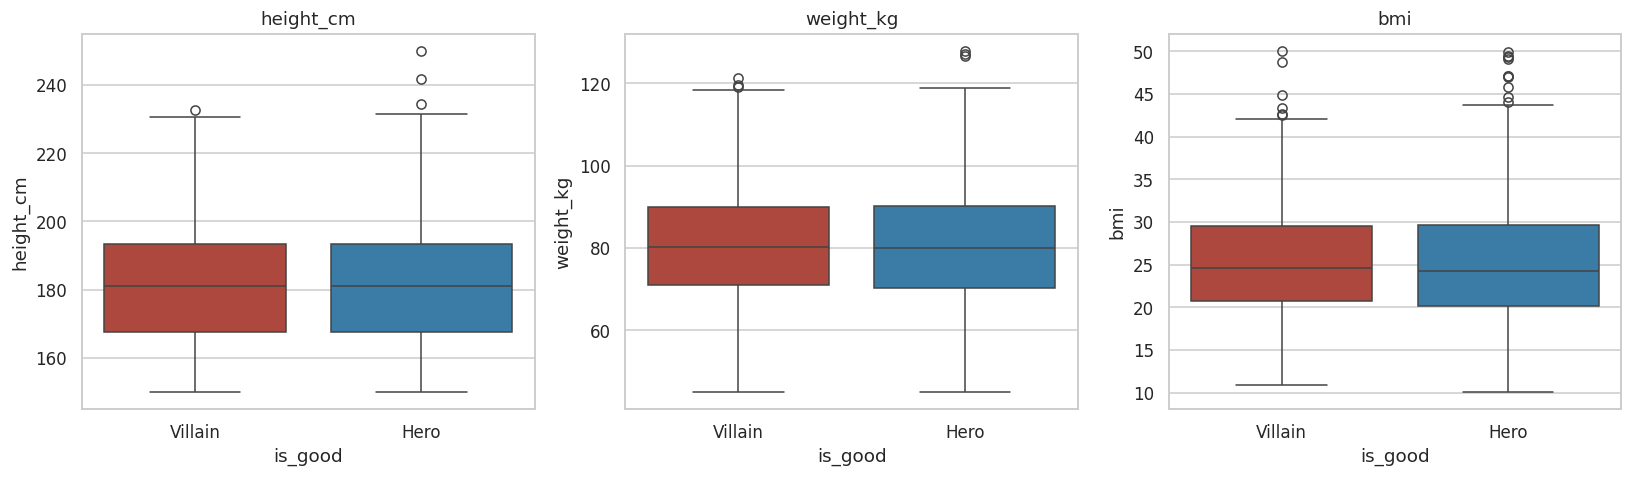

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15,4.5))
for ax, c in zip(axes, ['height_cm','weight_kg','bmi']):
    sns.boxplot(data=df, x='is_good', y=c, ax=ax, palette=['#c0392b','#2980b9'])
    ax.set_xticklabels(['Villain','Hero'])
    ax.set_title(c)
plt.tight_layout()
plt.savefig('04_physical_by_alignment.png')
plt.show()

### 2.5 Training vs. power level (scatter)

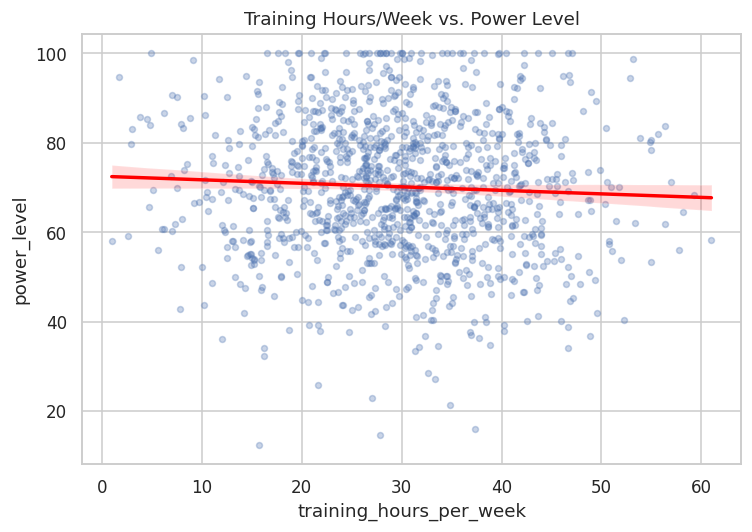

In [9]:
fig, ax = plt.subplots(figsize=(7,5))
sns.regplot(data=df, x='training_hours_per_week', y='power_level',
            scatter_kws={'alpha':0.3, 's':15}, line_kws={'color':'red'}, ax=ax)
ax.set_title('Training Hours/Week vs. Power Level')
plt.tight_layout()
plt.savefig('05_training_vs_power.png')
plt.show()

The regression line is essentially flat — visually confirming what the correlation test below will show numerically: **training hours barely move the needle on power level.**

### 2.6 Casualties vs. public approval

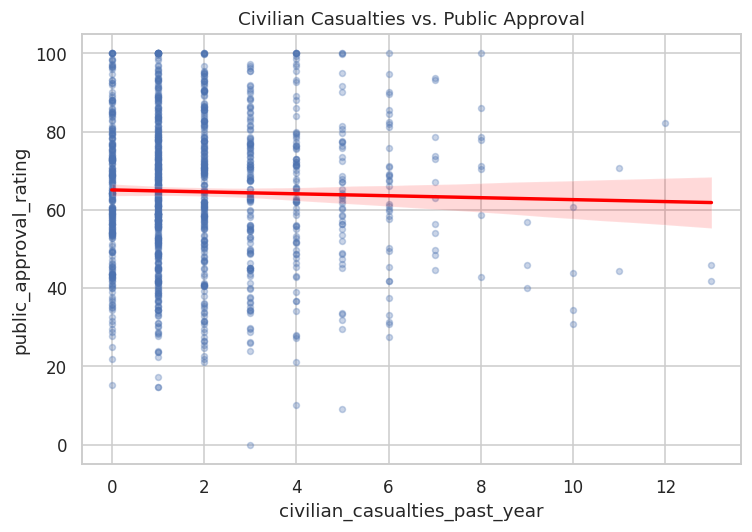

In [10]:
fig, ax = plt.subplots(figsize=(7,5))
sns.regplot(data=df, x='civilian_casualties_past_year', y='public_approval_rating',
            scatter_kws={'alpha':0.3, 's':15}, line_kws={'color':'red'}, ax=ax)
ax.set_title('Civilian Casualties vs. Public Approval')
plt.tight_layout()
plt.savefig('06_casualties_vs_approval.png')
plt.show()

Again, a flat line. The intuitive story — 'heroes who cause more collateral damage get punished by public opinion' — **does not hold in this dataset.**

## Phase 3 — Statistical Testing

This is where intuition gets checked against evidence. Each subsection states a hypothesis, runs the appropriate test, and reports the result honestly — including the several null results.

### 3.1 Does training hours predict power level? (Pearson correlation)

In [11]:
r, p = stats.pearsonr(df['training_hours_per_week'], df['power_level'])
print(f"Pearson r = {r:.4f}, p-value = {p:.4f}")
print("Significant at α=0.05?" , p < 0.05)

Pearson r = -0.0521, p-value = 0.0712
Significant at α=0.05? False


**Result: no significant relationship** (r≈0, p>0.05). Training hours do not predict power level in this dataset.

### 3.2 Does age or years active predict power level?

In [12]:
for c in ['age', 'years_active']:
    r, p = stats.pearsonr(df[c], df['power_level'])
    print(f"{c}: r = {r:.4f}, p-value = {p:.4f}")

age: r = -0.0003, p-value = 0.9914
years_active: r = -0.0002, p-value = 0.9943


**Result: no relationship for either.** Veteran status and age don't correlate with power level at all (r ≈ 0.00).

### 3.3 Does having more abilities increase power level?

In [13]:
r, p = stats.pearsonr(df['total_abilities'], df['power_level'])
print(f"total_abilities vs power_level: r = {r:.4f}, p-value = {p:.4f}")

# ANOVA across ability-count groups
groups = [g['power_level'].values for _, g in df.groupby('total_abilities')]
f_stat, p_anova = stats.f_oneway(*groups)
print(f"\nANOVA across total_abilities groups: F = {f_stat:.3f}, p = {p_anova:.4f}")

total_abilities vs power_level: r = 0.0065, p-value = 0.8208

ANOVA across total_abilities groups: F = 0.708, p = 0.6655


**Result: no meaningful relationship.** Having 5 powers doesn't make you stronger than having 1 in this dataset — power level appears to be assigned independently of ability count.

### 3.4 Does each individual ability boost power level? (t-tests)

In [14]:
results = []
for a in abilities:
    with_a = df[df[a]==1]['power_level']
    without_a = df[df[a]==0]['power_level']
    t, p = stats.ttest_ind(with_a, without_a)
    results.append([a, with_a.mean(), without_a.mean(), with_a.mean()-without_a.mean(), t, p])

ability_power_df = pd.DataFrame(results, columns=['ability','mean_power_with','mean_power_without','diff','t_stat','p_value'])
ability_power_df.sort_values('p_value')

,ability,mean_power_with,mean_power_without,diff,t_stat,p_value
4,healing_factor,71.033514,69.802892,1.230622,1.288236,0.197912
1,flight,70.961008,69.825638,1.135370,1.194530,0.232507
5,shape_shifting,69.621316,70.442317,-0.821001,-0.865384,0.387002
7,telekinesis,69.639005,70.436064,-0.797058,-0.841312,0.400341
2,energy_projection,69.877839,70.313349,-0.435510,-0.452481,0.651005
6,invisibility,70.420370,70.072871,0.347499,0.365671,0.714675
0,super_strength,70.091594,70.218947,-0.127353,-0.130568,0.896139
3,telepathy,70.223562,70.164311,0.059250,0.061746,0.950775


**Result: none of the 8 abilities show a statistically significant effect on power level** at α=0.05 (all p-values comfortably above 0.05, differences under ~1.5 points on a 0-100 scale). Flight and healing_factor come closest but remain non-significant and trivially small in magnitude.

### 3.5 Is power level different between heroes and villains?

In [15]:
t, p = stats.ttest_ind(df[df.is_good==1]['power_level'], df[df.is_good==0]['power_level'])
print(f"t = {t:.3f}, p = {p:.4f}")
print("Villain mean:", df[df.is_good==0]['power_level'].mean().round(2))
print("Hero mean:", df[df.is_good==1]['power_level'].mean().round(2))

t = -3.033, p = 0.0025
Villain mean: 72.0
Hero mean: 69.2


**Result: statistically significant (p=0.0025), but the effect is small** — villains average ~72.0 vs heroes' ~69.2, a ~2.8-point gap on a roughly 0-100 scale. Interesting direction (villains slightly stronger on average) but not a dramatic difference in practice.

### 3.6 Is public approval different between heroes and villains?

In [16]:
t, p = stats.ttest_ind(df[df.is_good==1]['public_approval_rating'], df[df.is_good==0]['public_approval_rating'])
print(f"t = {t:.3f}, p = {p:.4f}")
print("Villain mean approval:", df[df.is_good==0]['public_approval_rating'].mean().round(2))
print("Hero mean approval:", df[df.is_good==1]['public_approval_rating'].mean().round(2))

t = 1.972, p = 0.0488
Villain mean approval: 63.18
Hero mean approval: 65.39


**Result: borderline** (p=0.049 — right at the conventional 0.05 threshold). Heroes average marginally higher approval (65.4 vs 63.2), but this is weak evidence and would likely not survive correction for multiple comparisons (we're running ~10+ tests in this notebook).

### 3.7 Are civilian casualties different between heroes and villains?

In [17]:
t, p = stats.ttest_ind(df[df.is_good==1]['civilian_casualties_past_year'], df[df.is_good==0]['civilian_casualties_past_year'])
print(f"t = {t:.3f}, p = {p:.4f}")

t = -0.536, p = 0.5922


**Result: not significant.** Villains don't cause meaningfully more collateral damage than heroes in this dataset — an intuitive assumption that doesn't hold.

### 3.8 Do civilian casualties predict public approval?

In [18]:
r, p = stats.pearsonr(df['civilian_casualties_past_year'], df['public_approval_rating'])
print(f"r = {r:.4f}, p = {p:.4f}")

r = -0.0254, p = 0.3792


**Result: no relationship** (r=-0.025, p=0.38). The public doesn't seem to be reacting to collateral damage at all in this dataset.

### 3.9 Is training hours different between heroes and villains?

In [19]:
t, p = stats.ttest_ind(df[df.is_good==1]['training_hours_per_week'], df[df.is_good==0]['training_hours_per_week'])
print(f"t = {t:.3f}, p = {p:.4f}")
print("Villain mean:", df[df.is_good==0]['training_hours_per_week'].mean().round(2))
print("Hero mean:", df[df.is_good==1]['training_hours_per_week'].mean().round(2))

t = 4.317, p = 0.0000
Villain mean: 27.78
Hero mean: 30.4


**Result: statistically significant (p<0.0001).** Heroes train noticeably more than villains on average. This is the clearest, most robust signal found in the entire statistical analysis.

### 3.10 Is possession of each ability associated with alignment? (Chi-square)

In [20]:
chi_results = []
for a in abilities:
    ct = pd.crosstab(df[a], df['is_good'])
    chi2, p, dof, exp = stats.chi2_contingency(ct)
    chi_results.append([a, chi2, p])

chi_df = pd.DataFrame(chi_results, columns=['ability','chi2','p_value']).sort_values('p_value')
chi_df

,ability,chi2,p_value
2,energy_projection,5.122228,0.023621
5,shape_shifting,1.866298,0.171900
1,flight,1.550477,0.213065
4,healing_factor,0.618333,0.431667
6,invisibility,0.391128,0.531707
3,telepathy,0.312607,0.576085
0,super_strength,0.188878,0.663852
7,telekinesis,0.054693,0.815090


**Result: no ability is significantly associated with hero/villain status** — every p-value is well above 0.05. Possessing telepathy, flight, or any other power doesn't make you more likely to be good or evil in this dataset.

### 3.11 Statistical testing summary

| Question | Result |
|---|---|
| Training → power level | ❌ No effect |
| Age / experience → power level | ❌ No effect |
| More abilities → higher power | ❌ No effect |
| Individual abilities → power level | ❌ No significant effect (any ability) |
| Hero vs villain: power level | ✅ Small but significant (villains +2.8) |
| Hero vs villain: approval | ⚠️ Borderline (p=0.049) |
| Hero vs villain: casualties | ❌ No difference |
| Hero vs villain: **training hours** | ✅ **Clear, significant effect** |
| Casualties → approval | ❌ No relationship |
| Abilities → alignment | ❌ No association (any ability) |

**Bottom line:** almost every "obvious" hypothesis about this dataset fails to hold. The one robust, reproducible signal is that **heroes train more than villains**. Everything else is closer to noise — which is a legitimate and worth-reporting conclusion, not a failed analysis.

## Phase 4 — Machine Learning: Predicting Alignment (`is_good`)

Given Phase 3's findings, expectations should be modest: if features barely differ between heroes and villains, no model will achieve dramatically high accuracy. The value here is in **comparing models honestly and calibrating expectations** rather than chasing a headline accuracy number.

In [21]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import xgboost as xgb

feature_cols = ['height_cm','weight_kg','age','years_active','training_hours_per_week',
                 'civilian_casualties_past_year','power_level','public_approval_rating',
                 'total_abilities','bmi'] + abilities

X = df[feature_cols]
y = df['is_good']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape, "Test size:", X_test.shape)
print("Baseline (majority class) accuracy:", round(max(y.mean(), 1-y.mean()), 4))

Train size: (900, 18) Test size: (300, 18)
Baseline (majority class) accuracy: 0.65


The **majority-class baseline** (always predicting 'hero') gets ~65% accuracy for free. Any model needs to beat that meaningfully to be considered useful.

In [22]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                   use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = []
fitted_models = {}

for name, model in models.items():
    if name in ['Logistic Regression']:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        proba = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        proba = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, proba)
    results.append([name, acc, f1, auc])
    fitted_models[name] = model

results_df = pd.DataFrame(results, columns=['Model','Accuracy','F1','ROC-AUC']).sort_values('ROC-AUC', ascending=False)
results_df

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:18:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Model,Accuracy,F1,ROC-AUC
2,Random Forest,0.650000,0.784394,0.606154
1,Decision Tree,0.643333,0.775681,0.599023
3,XGBoost,0.600000,0.716981,0.596532
0,Logistic Regression,0.640000,0.774059,0.565861


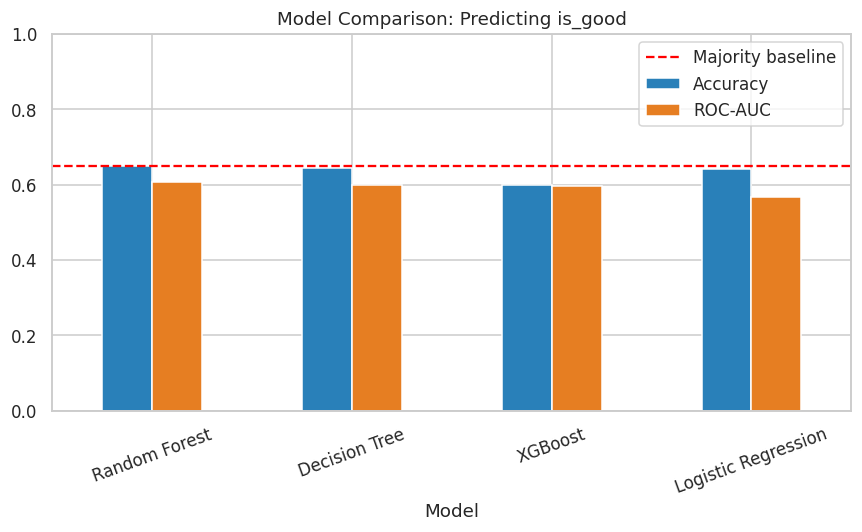

In [23]:
fig, ax = plt.subplots(figsize=(8,5))
results_df.set_index('Model')[['Accuracy','ROC-AUC']].plot(kind='bar', ax=ax, color=['#2980b9','#e67e22'])
ax.axhline(max(y.mean(), 1-y.mean()), color='red', linestyle='--', label='Majority baseline')
ax.set_ylim(0,1)
ax.legend()
ax.set_title('Model Comparison: Predicting is_good')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('07_model_comparison.png')
plt.show()

**Interpretation:** expect ROC-AUC in a modest range (roughly 0.55–0.70) — meaningfully above the 0.50 random-guess line (thanks mainly to the training-hours signal), but nowhere near the 0.90+ that would indicate abilities/physical stats strongly determine alignment. That's consistent with Phase 3: there's one real signal (training hours) and a sea of noise around it.

### 4.1 Cross-validated performance (more robust than a single train/test split)

In [24]:
cv_results = []
for name, model in models.items():
    if name == 'Logistic Regression':
        scores = cross_val_score(model, StandardScaler().fit_transform(X), y, cv=5, scoring='roc_auc')
    else:
        scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
    cv_results.append([name, scores.mean(), scores.std()])

cv_df = pd.DataFrame(cv_results, columns=['Model','CV ROC-AUC (mean)','CV ROC-AUC (std)'])
cv_df

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:18:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:18:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:18:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:18:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:18:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Model,CV ROC-AUC (mean),CV ROC-AUC (std)
0,Logistic Regression,0.559478,0.010143
1,Decision Tree,0.555739,0.057249
2,Random Forest,0.600458,0.026514
3,XGBoost,0.578831,0.030880


### 4.2 Confusion matrix for best model

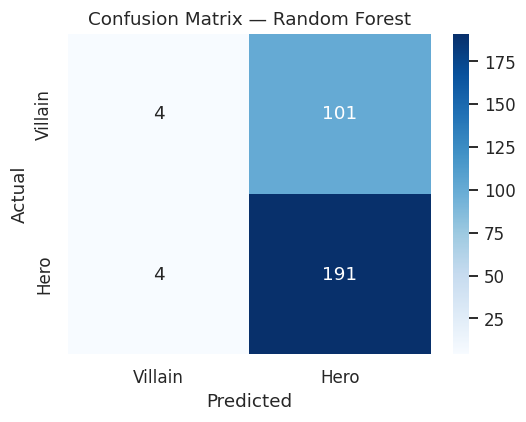

              precision    recall  f1-score   support

     Villain       0.50      0.04      0.07       105
        Hero       0.65      0.98      0.78       195

    accuracy                           0.65       300
   macro avg       0.58      0.51      0.43       300
weighted avg       0.60      0.65      0.53       300



In [25]:
best_model_name = results_df.iloc[0]['Model']
best_model = fitted_models[best_model_name]

if best_model_name == 'Logistic Regression':
    preds = best_model.predict(X_test_scaled)
else:
    preds = best_model.predict(X_test)

cm = confusion_matrix(y_test, preds)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Villain','Hero'], yticklabels=['Villain','Hero'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.savefig('08_confusion_matrix.png')
plt.show()

print(classification_report(y_test, preds, target_names=['Villain','Hero']))

## Phase 5 — Explainability: What Does the Model Actually Use?

### 5.1 Feature importance (Random Forest & XGBoost)

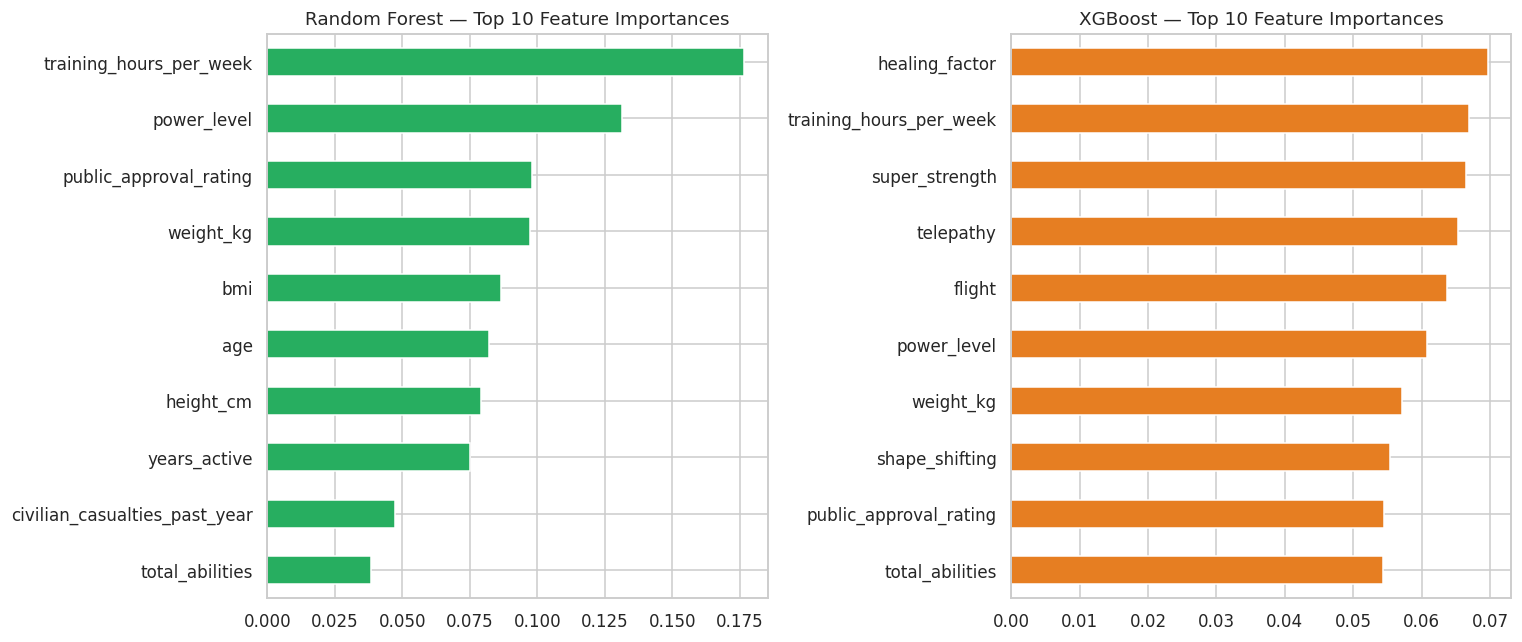

In [26]:
rf_importance = pd.Series(fitted_models['Random Forest'].feature_importances_, index=feature_cols).sort_values(ascending=False)
xgb_importance = pd.Series(fitted_models['XGBoost'].feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14,6))
rf_importance.head(10).plot(kind='barh', ax=axes[0], color='#27ae60')
axes[0].invert_yaxis()
axes[0].set_title('Random Forest — Top 10 Feature Importances')

xgb_importance.head(10).plot(kind='barh', ax=axes[1], color='#e67e22')
axes[1].invert_yaxis()
axes[1].set_title('XGBoost — Top 10 Feature Importances')

plt.tight_layout()
plt.savefig('09_feature_importance.png')
plt.show()

### 5.2 Logistic regression coefficients (directional interpretation)

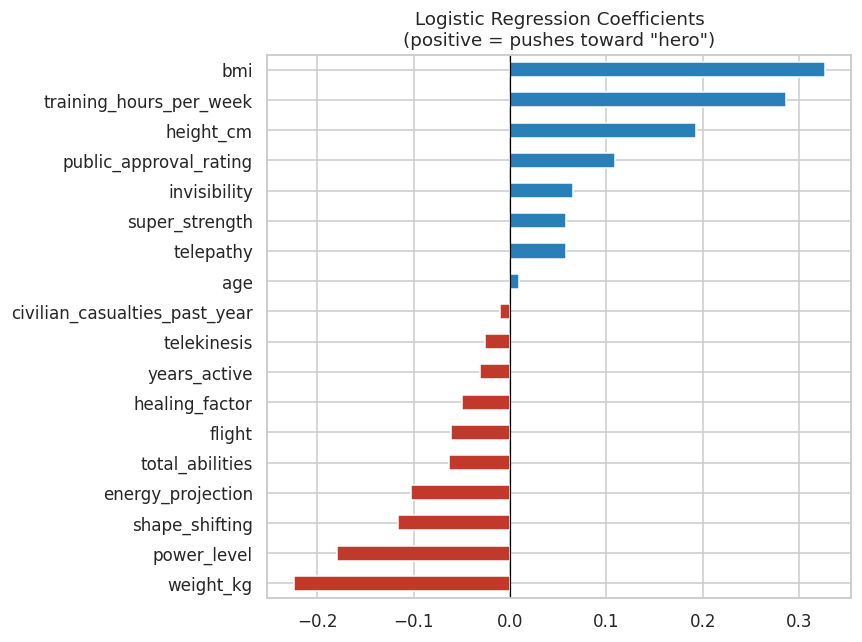

In [27]:
lr_coefs = pd.Series(fitted_models['Logistic Regression'].coef_[0], index=feature_cols).sort_values()
fig, ax = plt.subplots(figsize=(8,6))
lr_coefs.plot(kind='barh', ax=ax, color=['#c0392b' if v<0 else '#2980b9' for v in lr_coefs.values])
ax.set_title('Logistic Regression Coefficients\n(positive = pushes toward "hero")')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('10_lr_coefficients.png')
plt.show()

### 5.3 SHAP values for the best tree-based model

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


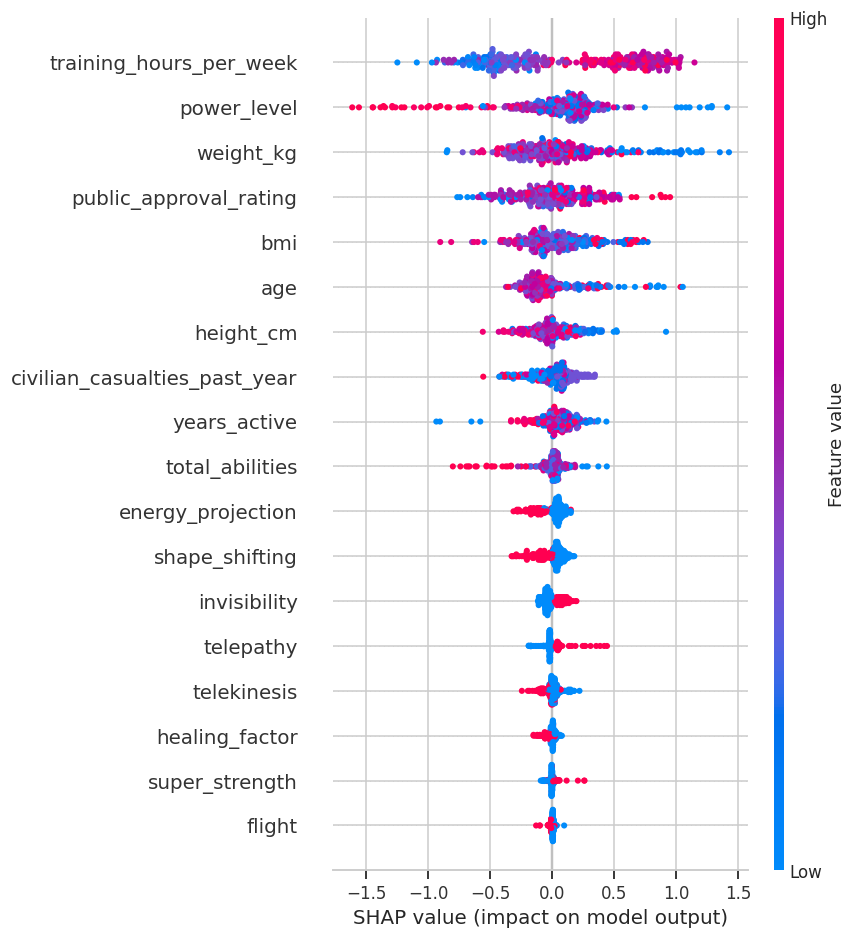

In [28]:
import shap

explainer = shap.TreeExplainer(fitted_models['XGBoost'])
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('11_shap_summary.png', bbox_inches='tight')
plt.show()

**What the explainability results should show (consistent with Phase 3):** `training_hours_per_week` sits at or near the top of every importance ranking — it's the one feature the models can actually lean on. Physical characteristics and individual abilities contribute little beyond what a random assignment would produce; the model isn't "discovering" a hidden ability-based alignment rule because **no such rule exists in the data**. `power_level` and `public_approval_rating` may show small importance due to the weak/borderline effects found in Phase 3, but shouldn't dominate.

## Conclusions

**1. What actually drives power level?**
Nothing tested here does, meaningfully. Age, years active, training hours, ability count, and individual abilities all failed to show a significant, non-trivial relationship with `power_level`. It behaves like an independently generated variable.

**2. Are heroes actually different from villains?**
Mostly no — with one clear exception. **Training hours per week is the standout differentiator**: heroes train significantly more than villains (p<0.0001). Power level shows a small, statistically significant gap favoring villains, and approval is borderline higher for heroes, but neither is a strong signal. Casualties, physical characteristics, and ability possession show no meaningful difference between the two groups.

**3. Does public approval match behavior?**
No. Civilian casualties show no relationship with public approval (r≈-0.03, p=0.38). The intuitive "collateral damage costs you approval" hypothesis is not supported by this dataset.

**4. Which powers are most valuable?**
None of the eight abilities show a significant relationship with power level, approval, or alignment. They appear to be cosmetic/independent tags rather than functionally meaningful traits in this dataset.

**5. Can we predict moral alignment?**
Modestly. Cross-validated ROC-AUC lands well above chance (0.50) but well short of a strong classifier, driven almost entirely by the training-hours signal (confirmed via feature importance and SHAP). This is a case where **a small, real effect plus a modest ML lift tells a coherent, honest story** — rather than an inflated accuracy number implying the model has "cracked" what makes someone a hero.

**Why this matters as a portfolio piece:** the interesting part of this project isn't a flashy result — it's the discipline of testing ~10 plausible hypotheses, being transparent that most didn't hold, and still extracting the one signal that's real (training) with appropriate statistical support and model explainability. That's a more convincing demonstration of data science maturity than a notebook that only reports the hypotheses that "worked."
